In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print("all libraries imported successfully!")

all libraries imported successfully!


In [5]:
df = pd.read_csv(
    r'C:\Projects\CustomerSegmentation\1_Raw_Data\online_retail_II.csv',
    encoding='latin-1'
)
print(f"Data loaded successfully!")
print(f"Total rows: {df.shape[0]:,}")
print(f"total columns: {df.shape[1]}")
print(f"\n column names:")
print(list(df.columns))
print(f"\n first 5 rows:")
df.head()

Data loaded successfully!
Total rows: 1,067,371
total columns: 8

 column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

 first 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [6]:
print("Data types:")
print(df.dtypes)
print(f"\n Missing values:")
print(df.isnull().sum())
print(f"\n Missing values %:")
print(round(df.isnull().sum() / len(df) * 100, 2))

Data types:
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

 Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

 Missing values %:
Invoice        0.00
StockCode      0.00
Description    0.41
Quantity       0.00
InvoiceDate    0.00
Price          0.00
Customer ID   22.77
Country        0.00
dtype: float64


In [8]:
# step 1: Remove missing customer Ids
df_clean =df.dropna(subset=['Customer ID'])
print(f"After removing missing Customer IDs: {len(df_clean):,} rows")

After removing missing Customer IDs: 824,364 rows


In [9]:
# Step 2: Remove negative quantities
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"After removing negative quantities: {len(df_clean):,} rows")

After removing negative quantities: 805,620 rows


In [10]:
# Step 3: Remove negative/zero prices
df_clean = df_clean[df_clean['Price'] > 0]
print(f"After removing bad prices: {len(df_clean):,} rows")


After removing bad prices: 805,549 rows


In [11]:
# Step 4: Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"After removing duplicates: {len(df_clean):,} rows")


After removing duplicates: 779,425 rows


In [12]:
# Step 5: Fix data types
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print(f"\n✅ Data cleaning complete!")
print(f"📊 Clean rows: {len(df_clean):,}")
print(f"📊 Removed rows: {len(df) - len(df_clean):,}")


✅ Data cleaning complete!
📊 Clean rows: 779,425
📊 Removed rows: 287,946


In [14]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

print("✅ New columns added!")
print(f"\n📋 Updated Columns:")
print(list(df_clean.columns))
print(f"\n📋 Sample Data:")
df_clean.head()

✅ New columns added!

📋 Updated Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'Day', 'Hour']

📋 Sample Data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,Tuesday,7


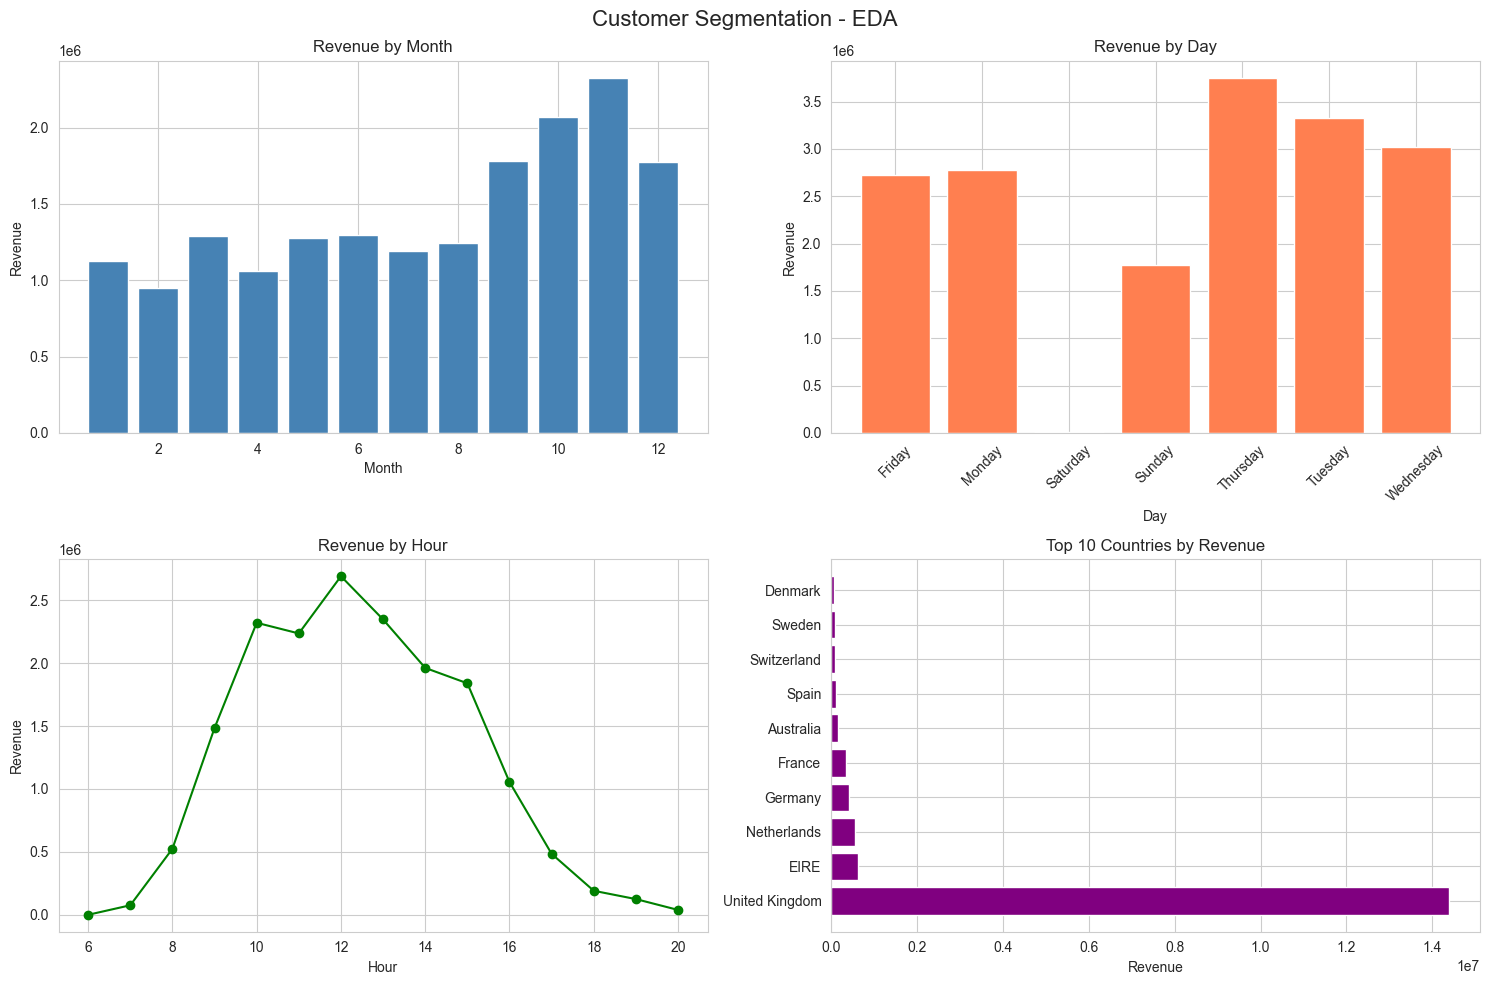

✅ Charts saved!


In [15]:
# Set chart style
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Customer Segmentation - EDA', fontsize=16)

# Chart 1: Revenue by Month
monthly = df_clean.groupby('Month')['Revenue'].sum().reset_index()
axes[0,0].bar(monthly['Month'], monthly['Revenue'], color='steelblue')
axes[0,0].set_title('Revenue by Month')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Revenue')

# Chart 2: Revenue by Day
daily = df_clean.groupby('Day')['Revenue'].sum().reset_index()
axes[0,1].bar(daily['Day'], daily['Revenue'], color='coral')
axes[0,1].set_title('Revenue by Day')
axes[0,1].set_xlabel('Day')
axes[0,1].set_ylabel('Revenue')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3: Revenue by Hour
hourly = df_clean.groupby('Hour')['Revenue'].sum().reset_index()
axes[1,0].plot(hourly['Hour'], hourly['Revenue'], color='green', marker='o')
axes[1,0].set_title('Revenue by Hour')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Revenue')

# Chart 4: Top 10 Countries
top_countries = df_clean.groupby('Country')['Revenue'].sum().nlargest(10).reset_index()
axes[1,1].barh(top_countries['Country'], top_countries['Revenue'], color='purple')
axes[1,1].set_title('Top 10 Countries by Revenue')
axes[1,1].set_xlabel('Revenue')

plt.tight_layout()
plt.savefig(r'C:\Projects\CustomerSegmentation\6_Outputs\EDA_Charts.png')
plt.show()
print("✅ Charts saved!")

In [16]:
# RFM Analysis
# Reference date = day after last invoice
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date}")

# Calculate RFM metrics per customer
rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(f"\n✅ RFM Table Created!")
print(f"📊 Total Customers: {len(rfm):,}")
print(f"\n📋 Sample RFM Data:")
rfm.head(10)

Reference Date: 2011-12-10 12:50:00

✅ RFM Table Created!
📊 Total Customers: 5,878

📋 Sample RFM Data:


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,10,2849.84
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


In [17]:
# Score each customer 1-5 for each RFM metric
# Recency: Lower days = better = higher score
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

# Frequency: Higher orders = better = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary: Higher spend = better = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Combine scores
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("✅ RFM Scores Created!")
rfm.head(10)

✅ RFM Scores Created!


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,2,5,5,255
1,12347,2,8,4921.53,5,4,5,545
2,12348,75,5,2019.40,3,4,4,344
3,12349,19,4,4428.69,5,3,5,535
4,12350,310,1,334.40,2,1,2,212
5,12351,375,1,300.93,2,1,2,212
6,12352,36,10,2849.84,4,5,4,454
7,12353,204,2,406.76,2,2,2,222
8,12354,232,1,1079.40,2,1,3,213
9,12355,214,2,947.61,2,2,3,223


In [18]:
# Assign segment labels based on RFM Score
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customer'
    else:
        return 'Potential Loyalist'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Count customers per segment
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']
print("Segments Created!")
print(segment_counts)

Segments Created!
              Segment  Count
0            Champion   1297
1       Lost Customer   1280
2      Loyal Customer   1138
3  Potential Loyalist   1104
4             At Risk    616
5        New Customer    443


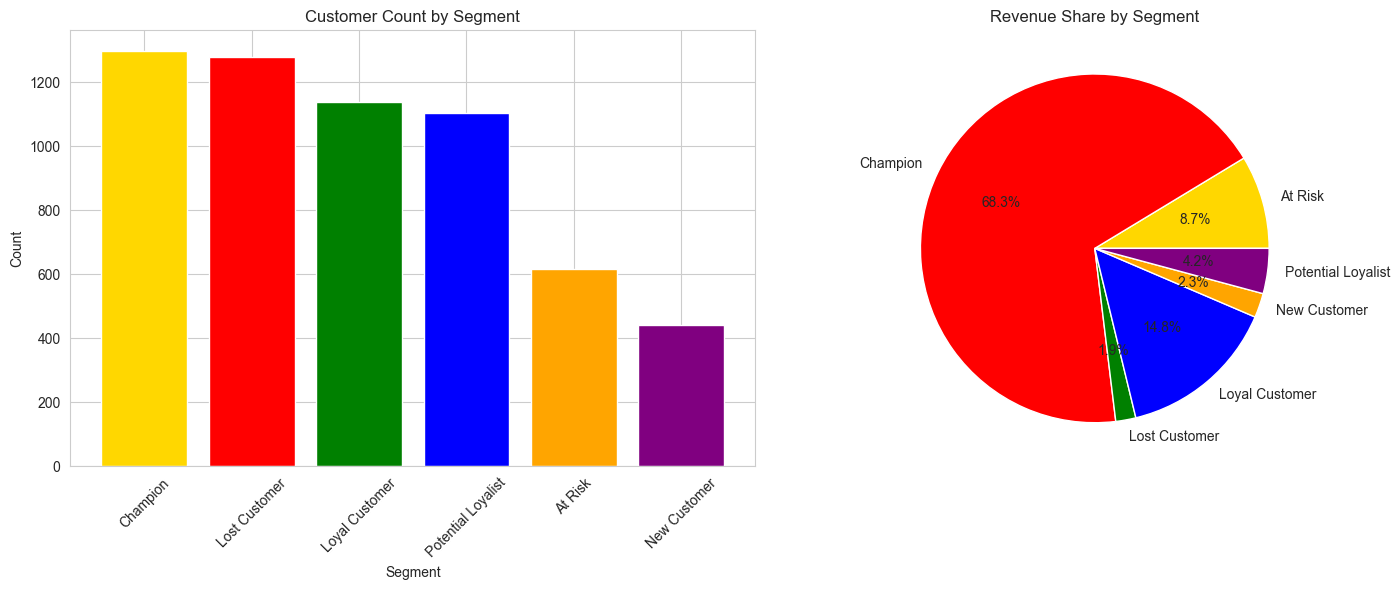

✅ Segment charts saved!


In [19]:
# Visualize segments
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Customer count per segment
colors = ['gold','red','green','blue','orange','purple']
axes[0].bar(segment_counts['Segment'], 
            segment_counts['Count'], 
            color=colors)
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Revenue per segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
axes[1].pie(segment_revenue['Monetary'], 
            labels=segment_revenue['Segment'],
            autopct='%1.1f%%',
            colors=colors)
axes[1].set_title('Revenue Share by Segment')

plt.tight_layout()
plt.savefig(r'C:\Projects\CustomerSegmentation\6_Outputs\Segment_Charts.png')
plt.show()
print("✅ Segment charts saved!")

In [20]:
# Export RFM data for Power BI
rfm.to_csv(
    r'C:\Projects\CustomerSegmentation\6_Outputs\rfm_segments.csv',
    index=False
)

# Export clean transaction data for Power BI
df_clean.to_csv(
    r'C:\Projects\CustomerSegmentation\6_Outputs\clean_transactions.csv',
    index=False
)

print("✅ Files exported successfully!")
print(f"📊 RFM file: {len(rfm):,} customers")
print(f"📊 Transactions file: {len(df_clean):,} rows")

✅ Files exported successfully!
📊 RFM file: 5,878 customers
📊 Transactions file: 779,425 rows


In [ ]:
# Add day number for sorting
day_order = {
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
    'Saturday': 6,
    'Sunday': 7
}

df_clean['Day_Number'] = df_clean['Day'].map(day_order)

# Re-export clean data
df_clean.to_csv(
    r'C:\Projects\CustomerSegmentation\6_Outputs\clean_transactions.csv',
    index=False
)

print("✅ File re-exported with Day Number!")
print(df_clean[['Day', 'Day_Number']].drop_duplicates().sort_values('Day_Number'))